In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter
from IPython.display import display, Math


In [66]:
display(Math(r"""
\begin{align}
r_{\text{ceiling}} &= \frac{2 r_{\text{half}}}{1 + r_{\text{half}}} \tag{1} \\[2.5em]
\text{MSE}_{r_{\text{unbiased}}} &< \text{MSE}_{r} \tag{2} \\[1.5em]
\frac{\text{MSE}_{r_{\text{unbiased}}}}{\text{MSE}_{r}} &< 1 \tag{3} \\[1.5em]
\widehat{\text{RMSE}}_{r} &= \widehat{\text{Var}}(r) + \widehat{\text{Bias}}(r)^2 \tag{2} \\[0.5em]
&= \frac{(1 - r^2)^2}{N - 1} + \left(\frac{r}{r_{\text{ceiling}}} - r\right)^2 \nonumber \\[2.5em]
\widehat{\text{RMSE}}_{r_{\text{unbiased}}} &= \frac{\widehat{\text{Var}}(r)}{r_{\text{ceiling}}^2} \tag{3} \\[1.5em]
&= \frac{(1 - r^2)^2}{r_{\text{ceiling}}^2 (N - 1)} \nonumber
\end{align}
"""))

<IPython.core.display.Math object>

In [3]:
from IPython.display import display, Math

display(Math(r"""
\begin{align}
\text{MSE}_{R} &\approx \text{Var}(R) + \left(R - \rho\right)^2 \\[1em]
\text{MSE}_{R_\text{unbiased}} &\approx \frac{\text{Var}(R)}{R_{\text{ceiling}}^2}
\end{align}
"""))

display(Math(r"\text{where } \text{Var}(R) \approx \frac{(1 - R^2)^2}{N - 1} \quad \text{and} \quad \rho \approx \frac{R}{R_{\text{ceiling}}}. "))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

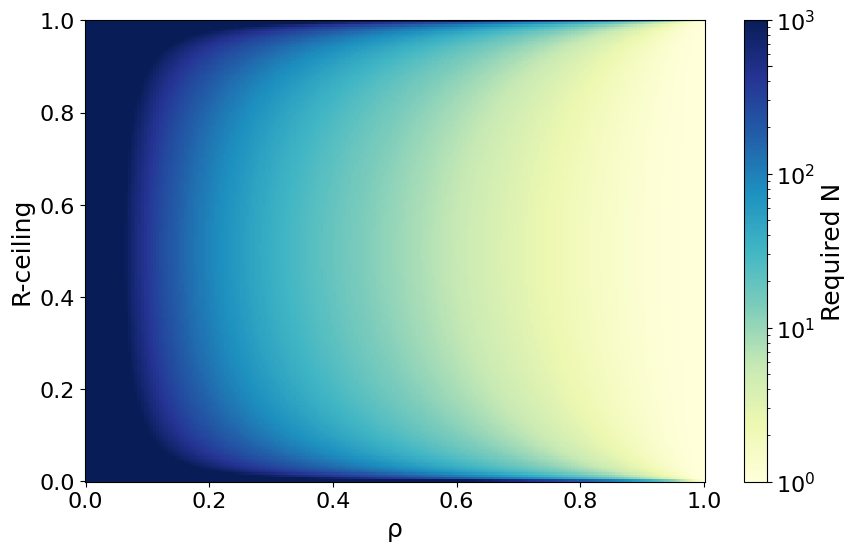

In [4]:
# Create grid for ρ and R-ceiling
rhos = np.linspace(0.001, 0.999, 200)
Rceilings = np.linspace(0.001, 0.999, 200)
Rho_grid, Rceiling_grid = np.meshgrid(rhos, Rceilings)

# Compute N on the grid
N = 1 + ((1 - Rho_grid**2)**2 / (Rho_grid**2)) / (Rceiling_grid * (1 - Rceiling_grid))

# Plot 2D heatmap with a log-scale color mapping
plt.figure(figsize=(10, 6))
pcm = plt.pcolormesh(
    Rho_grid, Rceiling_grid, N,
    shading='auto',
    cmap='YlGnBu',
    norm=LogNorm(vmin=1, vmax=1000)
)

# Labeling and styling
plt.xlabel('ρ', size=18)
plt.ylabel('R-ceiling', size=18)
#plt.title('Required N as a function of ρ and R-ceiling (log color scale)', size=10)
plt.xticks(size=16)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], size=16)

# Colorbar with log scale and selected ticks
cbar = plt.colorbar(pcm, ticks=[1, 10, 100, 500, 1000])
cbar.ax.tick_params(labelsize=16)
cbar.ax.yaxis.label.set_size(18)
cbar.set_label('Required N', size=18)

plt.show()


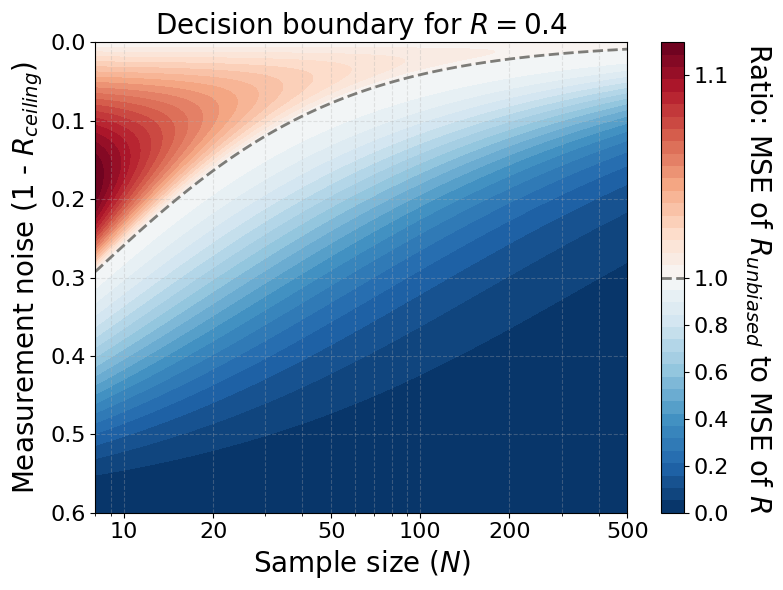

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.colors import TwoSlopeNorm

def calculate_mse_ratio(n, r_ceiling, R):
    """
    Calculates the ratio of MSE_unbiased to MSE_raw based on:
    1. Var(R) ~= ((1 - rho^2)^2) / (N - 1)
    2. MSE_raw ~= Var(R) + [rho * (1 - R_ceiling)]^2
    3. MSE_unbiased ~= Var(R) / R_ceiling
    where rho ~= R / R_ceiling
    """
    # Calculate rho from R and R_ceiling
    rho = R / r_ceiling
    
    # Equation [5]: Approximate Variance of R
    var_r = ((1 - rho**2)**2) / (n - 1)
    
    # Equation [1]: MSE Raw
    # Note: The bias term is squared: [rho(1 - R_ceiling)]^2
    bias_squared = (rho * (1 - r_ceiling))**2
    mse_raw = var_r + bias_squared
    
    # Equation [2]: MSE Unbiased
    # Note: Image implies MSE_unbiased is Var(R) scaled by 1/R_ceiling
    mse_unbiased = var_r / r_ceiling
    
    return mse_unbiased / mse_raw


def plot_mse_ratio_heatmap(R_value):
    # --- Configuration ---
    n_min, n_max = 8, 500
    r_min, r_max = 0.4, 1.0

    # --- Data Generation ---
    # Increased resolution (200 -> 500) for smoother contours and better label rotation
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    r_range = np.linspace(r_min, r_max, 500)
    N, R_Ceiling = np.meshgrid(n_range, r_range)

    # Calculate the Ratio Matrix
    Ratio = calculate_mse_ratio(N, R_Ceiling, R_value)

    # --- Plotting ---
    plt.figure(figsize=(8, 6))

    # Define custom levels to ensure equal banding density in both regions
    # 50 levels for the blue region (min to 1) and 50 for the red region (1 to max)
    levels_blue = np.linspace(Ratio.min(), 1.0, 20)
    levels_red = np.linspace(1.0, Ratio.max(), 20)
    # Combine and remove duplicate 1.0
    levels = np.unique(np.concatenate([levels_blue, levels_red]))

    # Create a TwoSlopeNorm centered at 1.0
    norm = TwoSlopeNorm(vmin=Ratio.min(), vcenter=1.0, vmax=Ratio.max())

    # Create the filled contour plot (Heatmap)
    # Passing 'levels' forces distinct bands in the lower range
    cp = plt.contourf(N, R_Ceiling, Ratio, levels=levels, cmap='RdBu_r', norm=norm)

    # --- FIX FOR LINE AND LABEL ---
    # 1. Create a copy of the data for the line contour
    Ratio_line = Ratio.copy()
    
    # 2. Mask the top edge (where R_ceiling is effectively 1.0)
    Ratio_line[np.isclose(R_Ceiling, 1.0)] = np.nan

    # 3. Plot the contour line using the masked data
    line_contour = plt.contour(N, R_Ceiling, Ratio_line, levels=[1.0], colors=plt.cm.cividis(0.5), linewidths=2, linestyles='--')
    
    # Add a colorbar
    cbar = plt.colorbar(cp, ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.1])
    cbar.set_label(r'Ratio: MSE of $R_{unbiased}$ to MSE of $R$', rotation=270, labelpad=32, fontsize=20)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.axhline(y=1.0, color=plt.cm.cividis(0.5), linestyle='--', linewidth=2)
    
    # --- Log Scale Configuration ---
    plt.xscale('log')
    plt.ylim(0.4, 1)

    # Set specific ticks
    ticks = [10, 20, 50, 100, 200, 500]
    plt.xticks(ticks, labels=[str(t) for t in ticks])

    # Remove scientific notation
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())

    # --- Y-Axis Customization (Measurement Noise) ---
    # We want to display (1 - R_ceiling) on the Y-axis.
    # Since we plotted R_ceiling (0.4 to 1.0), the noise is (0.6 to 0.0).
    # We use a FuncFormatter to transform the tick labels.
    def noise_formatter(x, pos):
        return f"{1 - x:.1f}"

    plt.gca().yaxis.set_major_formatter(FuncFormatter(noise_formatter))
    
    # Ensure nice ticks happen at 0.1 intervals of Noise
    # Noise = 0.0, 0.1, ... 0.6 correspond to R_ceil = 1.0, 0.9, ... 0.4
    r_ceil_ticks = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    plt.yticks(r_ceil_ticks)

    # Labels and Title
    plt.xlabel('Sample size ($N$)', fontsize=20)
    plt.ylabel(r'Measurement noise (1 - $R_{ceiling}$)', fontsize=20)
    plt.title(f'Decision boundary for $R = {R_value}$', fontsize=20)
    plt.xticks(size=16)
    plt.yticks(size=16)

    # Add grid
    plt.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.3)

    # Show plot
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_mse_ratio_heatmap(R_value=0.4)

PLOT WITH VARIOUS CONTOURS FOR R

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/4282771033.py:130: RuntimeWarning: divide by zero encountered in divide
  return mse_raw / mse_unbiased


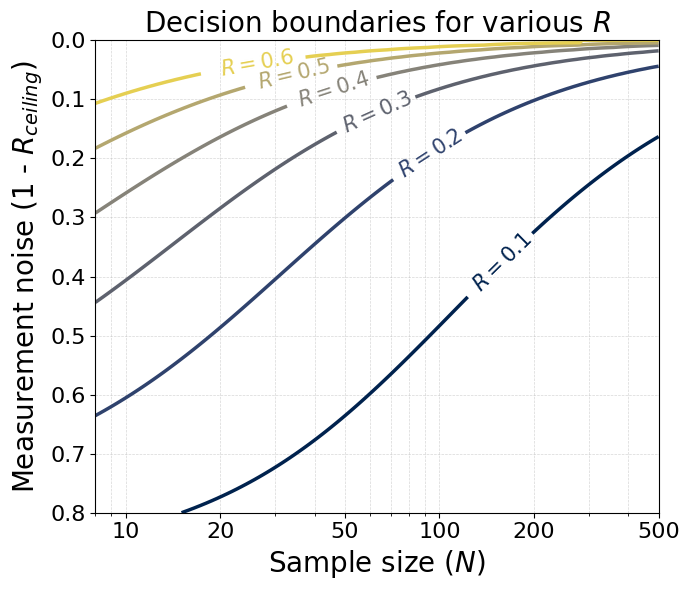

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.colors import TwoSlopeNorm

def calculate_mse_ratio(n, r_ceiling, R):
    """
    Calculates the ratio of MSE_unbiased to MSE_raw based on:
    1. Var(R) ~= ((1 - rho^2)^2) / (N - 1)
    2. MSE_raw ~= Var(R) + [rho * (1 - R_ceiling)]^2
    3. MSE_unbiased ~= Var(R) / R_ceiling
    where rho ~= R / R_ceiling
    """
    # Calculate rho from R and R_ceiling
    rho = R / r_ceiling
    
    # Equation [5]: Approximate Variance of R
    var_r = ((1 - rho**2)**2) / (n - 1)
    
    # Equation [1]: MSE Raw
    # Note: The bias term is squared: [rho(1 - R_ceiling)]^2
    bias_squared = (rho * (1 - r_ceiling))**2
    mse_raw = var_r + bias_squared
    
    # Equation [2]: MSE Unbiased
    # Note: Image implies MSE_unbiased is Var(R) scaled by 1/R_ceiling
    mse_unbiased = var_r / r_ceiling
    
    return mse_unbiased / mse_raw


def plot_mse_ratio_heatmap(R_value):
    # --- Configuration ---
    n_min, n_max = 8, 500
    r_min, r_max = 0.4, 1.0

    # --- Data Generation ---
    # Increased resolution (200 -> 500) for smoother contours and better label rotation
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    r_range = np.linspace(r_min, r_max, 500)
    N, R_Ceiling = np.meshgrid(n_range, r_range)

    # Calculate the Ratio Matrix
    Ratio = calculate_mse_ratio(N, R_Ceiling, R_value)

    # --- Plotting ---
    plt.figure(figsize=(8, 6))

    # Define custom levels to ensure equal banding density in both regions
    # 50 levels for the blue region (min to 1) and 50 for the red region (1 to max)
    levels_blue = np.linspace(Ratio.min(), 1.0, 50)
    levels_red = np.linspace(1.0, Ratio.max(), 50)
    # Combine and remove duplicate 1.0
    levels = np.unique(np.concatenate([levels_blue, levels_red]))

    # Create a TwoSlopeNorm centered at 1.0
    norm = TwoSlopeNorm(vmin=Ratio.min(), vcenter=1.0, vmax=Ratio.max())

    # Create the filled contour plot (Heatmap)
    # Passing 'levels' forces distinct bands in the lower range
    cp = plt.contourf(N, R_Ceiling, Ratio, levels=levels, cmap='RdBu_r', norm=norm)

    # --- FIX FOR LINE AND LABEL ---
    # 1. Create a copy of the data for the line contour
    Ratio_line = Ratio.copy()
    
    # 2. Mask the top edge (where R_ceiling is effectively 1.0)
    Ratio_line[np.isclose(R_Ceiling, 1.0)] = np.nan

    # 3. Plot the contour line using the masked data
    line_contour = plt.contour(N, R_Ceiling, Ratio_line, levels=[1.0], colors=plt.cm.cividis(0.5), linewidths=2, linestyles='--')
    
    # Add a colorbar
    cbar = plt.colorbar(cp, ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.1])
    cbar.set_label(r'Ratio: MSE of $R_{unbiased}$ to MSE of $R$', rotation=270, labelpad=32, fontsize=20)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.axhline(y=1.0, color=plt.cm.cividis(0.5), linestyle='--', linewidth=2)
    
    # --- Log Scale Configuration ---
    plt.xscale('log')
    plt.ylim(0.4, 1)

    # Set specific ticks
    ticks = [10, 20, 50, 100, 200, 500]
    plt.xticks(ticks, labels=[str(t) for t in ticks])

    # Remove scientific notation
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())

    # --- Y-Axis Customization (Measurement Noise) ---
    # We want to display (1 - R_ceiling) on the Y-axis.
    # Since we plotted R_ceiling (0.4 to 1.0), the noise is (0.6 to 0.0).
    # We use a FuncFormatter to transform the tick labels.
    def noise_formatter(x, pos):
        return f"{1 - x:.1f}"

    plt.gca().yaxis.set_major_formatter(FuncFormatter(noise_formatter))
    
    # Ensure nice ticks happen at 0.1 intervals of Noise
    # Noise = 0.0, 0.1, ... 0.6 correspond to R_ceil = 1.0, 0.9, ... 0.4
    r_ceil_ticks = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    plt.yticks(r_ceil_ticks)

    # Labels and Title
    plt.xlabel('Sample size ($N$)', fontsize=20)
    plt.ylabel(r'Measurement noise (1 - $R_{ceiling}$)', fontsize=20)
    plt.title(f'Decision boundary for $R = {R_value}$', fontsize=20)
    plt.xticks(size=16)
    plt.yticks(size=16)

    # Add grid
    plt.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.3)

    # Show plot
    plt.tight_layout()
    plt.show()

# --- CONTOUR PLOT FUNCTION (Added per request) ---

def calculate_mse_ratio_contour(n, r_ceiling, R):
    """
    Calculates the ratio of MSE_raw to MSE_unbiased.
    Returns: MSE_raw / MSE_unbiased
    """
    rho = R / r_ceiling
    var_r = ((1 - rho**2)**2) / (n - 1)
    bias_squared = (rho * (1 - r_ceiling))**2
    mse_raw = var_r + bias_squared
    mse_unbiased = var_r / r_ceiling
    return mse_raw / mse_unbiased

def solve_r_ceiling_for_fixed_n(n_target, N_grid, R_Ceiling_grid, Ratio_grid):
    """
    Finds the R_ceiling value where Ratio=1.0 for a fixed N.
    Uses interpolation on the generated grid data.
    """
    # Get the unique N values (x-axis) from the grid
    n_values = N_grid[0, :]
    
    # Find the column index in the grid closest to n_target
    idx = np.abs(n_values - n_target).argmin()
    
    # Extract the R_ceiling and Ratio columns at this N
    r_ceil_col = R_Ceiling_grid[:, idx]
    ratio_col = Ratio_grid[:, idx]
    
    # We need to find r_ceil where ratio_col == 1.0
    # np.interp expects the x-coordinate (ratio) to be sorted/increasing
    sorted_indices = np.argsort(ratio_col)
    ratio_sorted = ratio_col[sorted_indices]
    r_ceil_sorted = r_ceil_col[sorted_indices]
    
    # Interpolate to find the R_ceiling value
    return np.interp(1.0, ratio_sorted, r_ceil_sorted)

def plot_mse_ratio_contours():
    # --- Configuration ---
    # Contours for "R" (Naive Correlation / Rho)
    r_naive_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
    
    # Spacing adjustments for labels
    spacings = [15, 0, -10, -15, -20, -23] 
    
    n_min, n_max = 8, 500
    r_ceil_min, r_ceil_max = 0.2, 1.0  # Updated Y-axis range
    
    # Target X-value (Sample Size) for all labels (Vertical alignment)
    label_n_fixed = 10

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 200)
    r_ceil_range = np.linspace(r_ceil_min, r_ceil_max, 200)
    
    # Grid: N on X, R_ceiling on Y
    N, R_Ceiling = np.meshgrid(n_range, r_ceil_range)

    # --- Plotting ---
    plt.figure(figsize=(7, 6))

    # Create distinct colors for the contours
    colors = plt.cm.cividis(np.linspace(0, 0.9, len(r_naive_values)))

    for i, r_val in enumerate(r_naive_values):
        # Calculate Ratio for current Naive R
        # Note: This uses the function definition where it returns raw/unbiased
        Ratio = calculate_mse_ratio_contour(N, R_Ceiling, r_val)
        
        # --- Mask Invalid Regions ---
        # Mask where R_ceiling < R (impossible region)
        Ratio = np.ma.masked_where(R_Ceiling < r_val, Ratio)
        
        # Plot the contour line where Ratio = 1.0
        CS = plt.contour(
            N, R_Ceiling, Ratio, 
            levels=[1.0], 
            colors=[colors[i]], 
            linewidths=2.5, linestyles='-'
        )
        
        # Calculate the exact R_ceiling where this curve crosses our target N
        # We need to pass the raw data (not masked) for interpolation logic if possible,
        # or handle NaNs. The masked array works if interpolation respects mask or we fill.
        # However, for finding the label position, simple interpolation is usually fine
        # unless the label point itself is masked.
        
        # To avoid issues with masked arrays in custom interpolation function:
        # We'll pass the filled version but the logic handles sorting.
        label_r_ceil_pos = solve_r_ceiling_for_fixed_n(label_n_fixed, N, R_Ceiling, Ratio.filled(np.nan))
        
        # Add label at the calculated manual position if it's within plot range AND valid
        if r_ceil_min <= label_r_ceil_pos <= r_ceil_max and label_r_ceil_pos >= r_val:
            plt.clabel(
                CS, 
                inline=True, 
                fontsize=15, 
                fmt={1.0: f'$R = {r_val}$'},
                manual=[(label_n_fixed, label_r_ceil_pos)],
                use_clabeltext=True,
                inline_spacing=spacings[i]
            )

    # --- Log Scale Configuration ---
    plt.xscale('log')
    
    # Ensure tick labels are readable integers
    ticks = [10, 20, 50, 100, 200, 500]
    plt.xticks(ticks, labels=[str(t) for t in ticks])
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())

    # --- Y-Axis Customization (Measurement Noise) ---
    def noise_formatter(x, pos):
        return f"{1 - x:.1f}"

    plt.gca().yaxis.set_major_formatter(FuncFormatter(noise_formatter))
    
    # Ensure nice ticks happen at 0.1 intervals of Noise
    r_ceil_ticks = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    plt.yticks(r_ceil_ticks)

    # Labels and Title
    plt.xlabel(r'Sample size ($N$)', fontsize=20)
    plt.ylabel(r'Measurement noise (1 - $R_{ceiling}$)', fontsize=20)
    plt.title(r'Decision boundaries for various $R$', fontsize=20)
    plt.xticks(size=16)
    plt.yticks(size=16)
    plt.ylim(0.2, 1.0) # Updated limits per request (covering 0.2 to 1.0)

    plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # You can choose which plot to run. 
    # plot_mse_ratio_heatmap(R_value=0.4)
    plot_mse_ratio_contours()

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/1152863199.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


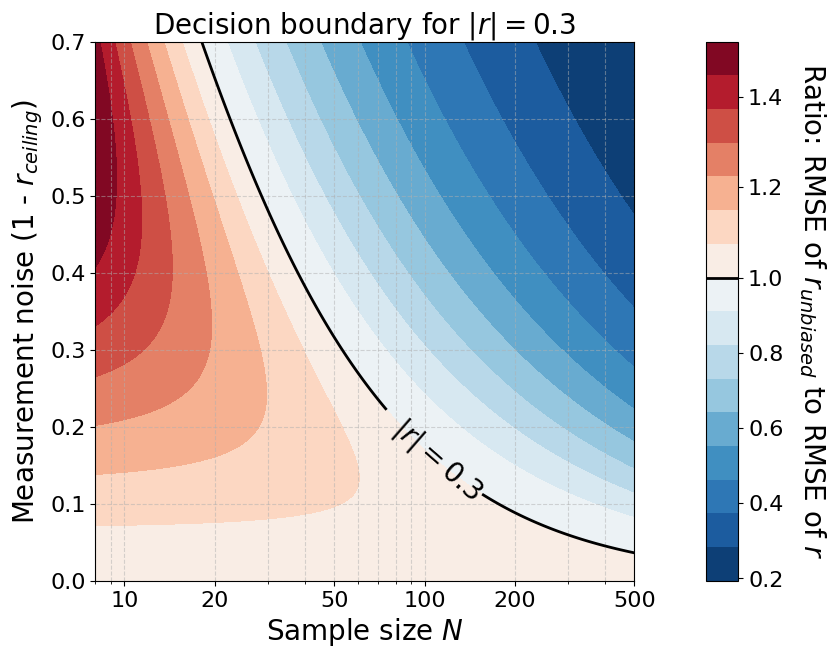

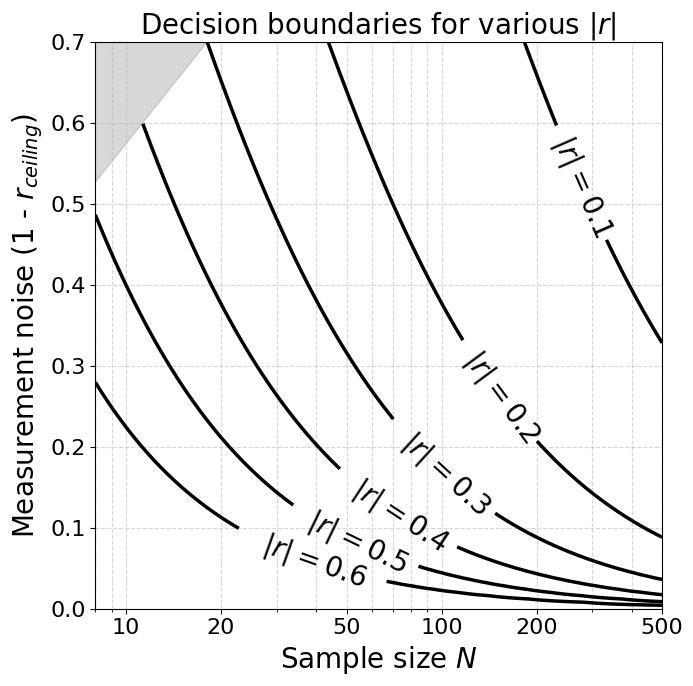

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.colors import TwoSlopeNorm

def calculate_rmse_ratio(n, r_ceiling, r):
    """
    Calculates the ratio of RMSE_unbiased to RMSE_raw based on:
    1. Var(r) ~= ((1 - r^2)^2) / (N - 1)
    2. RMSE_raw ~= sqrt(Var(r) + [rho * (1 - r_ceiling)]^2)
    3. RMSE_unbiased ~= sqrt(Var(r) / r_ceiling^2)
    where rho ~= r / r_ceiling
    """
    rho = r / r_ceiling
    var_r = ((1 - r**2)**2) / (n - 1)
    bias_squared = (rho * (1 - r_ceiling))**2
    rmse_raw = np.sqrt(var_r + bias_squared)
    rmse_unbiased = np.sqrt(var_r / (r_ceiling**2))
    
    return rmse_unbiased / rmse_raw


def find_termination_n(r_val):
    """
    Calculate the N value where the ratio = 1 contour terminates at r_ceiling = r_val.
    Derived analytically by setting ratio = 1 and r_ceiling = r.
    """
    return 1 + (1 - r_val) * (1 + r_val)**3 / r_val**2


def plot_rmse_ratio_heatmap(r_value):
    # --- Configuration ---
    n_min, n_max = 8, 500
    r_min, r_max = 0.3, 1.0

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    r_range = np.linspace(r_min, r_max, 500)
    n_grid, r_ceiling_grid = np.meshgrid(n_range, r_range)

    # Calculate the Ratio Matrix
    ratio = calculate_rmse_ratio(n_grid, r_ceiling_grid, r_value)

    # --- Plotting with gridspec for colorbar sizing ---
    fig = plt.figure(figsize=(9, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.05], wspace=0.05)
    ax = fig.add_subplot(gs[0])
    cax = fig.add_subplot(gs[1])

    # Define custom levels to ensure equal banding density in both regions
    levels_blue = np.linspace(ratio.min(), 1.0, 10)
    levels_red = np.linspace(1.0, ratio.max(), 8)
    levels = np.unique(np.concatenate([levels_blue, levels_red]))

    # Create a TwoSlopeNorm centered at 1.0
    norm = TwoSlopeNorm(vmin=ratio.min(), vcenter=1.0, vmax=ratio.max())

    # Create the filled contour plot (Heatmap)
    cp = ax.contourf(n_grid, r_ceiling_grid, ratio, levels=levels, cmap='RdBu_r', norm=norm)

    # --- FIX FOR LINE AND LABEL ---
    ratio_line = ratio.copy()
    ratio_line[np.isclose(r_ceiling_grid, 1.0)] = np.nan

    line_contour = ax.contour(n_grid, r_ceiling_grid, ratio_line, levels=[1.0], colors=['black'], linewidths=2, linestyles='-')
    
    # --- ADD LABEL ---
    target_n = 40
    idx_n = np.abs(n_range - target_n).argmin()
    idx_r = np.abs(ratio[:, idx_n] - 1.0).argmin() 
    
    label_n = n_range[idx_n]
    label_r = r_range[idx_r]

    ax.clabel(
        line_contour, 
        inline=True, 
        fontsize=20, 
        fmt={1.0: f'$|r| = {r_value}$'}, 
        manual=[(label_n, label_r)],
        use_clabeltext=True,
        inline_spacing=15
    )

    # Add a colorbar
    cbar = fig.colorbar(cp, cax=cax, ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2])
    cbar.set_label(r'Ratio: RMSE of $r_{unbiased}$ to RMSE of $r$', rotation=270, labelpad=32, fontsize=20)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.axhline(y=1.0, color='black', linestyle='-', linewidth=2)
    
    # --- Log Scale Configuration ---
    ax.set_xscale('log')
    ax.set_ylim(1.0, 0.3)

    ticks = [10, 20, 50, 100, 200, 500]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.xaxis.set_major_formatter(ScalarFormatter())

    # --- Y-Axis Customization (Measurement Noise) ---
    def noise_formatter(x, pos):
        return f"{1 - x:.1f}"

    ax.yaxis.set_major_formatter(FuncFormatter(noise_formatter))
    
    r_ceil_ticks = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    ax.set_yticks(r_ceil_ticks)

    # Labels and Title
    ax.set_xlabel('Sample size $N$', fontsize=20)
    ax.set_ylabel(r'Measurement noise (1 - $r_{ceiling}$)', fontsize=20)
    ax.set_title(f'Decision boundary for $|r| = {r_value}$', fontsize=20)
    ax.tick_params(axis='both', labelsize=16)

    ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
    
    # Make plot square
    ax.set_box_aspect(1)
    
    plt.tight_layout()
    plt.show()


# --- CONTOUR PLOT FUNCTION ---

def solve_r_ceiling_for_fixed_n(n_target, n_grid, r_ceiling_grid, ratio_grid):
    """
    Finds the r_ceiling value where ratio=1.0 for a fixed N.
    Uses interpolation on the generated grid data.
    """
    n_values = n_grid[0, :]
    idx = np.abs(n_values - n_target).argmin()
    
    r_ceil_col = r_ceiling_grid[:, idx]
    ratio_col = ratio_grid[:, idx]
    
    sorted_indices = np.argsort(ratio_col)
    ratio_sorted = ratio_col[sorted_indices]
    r_ceil_sorted = r_ceil_col[sorted_indices]
    
    return np.interp(1.0, ratio_sorted, r_ceil_sorted)


def plot_rmse_ratio_contours():
    # --- Configuration ---
    r_naive_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
    spacings = [20, 10, 5, -5, -15, -20] 
    
    n_min, n_max = 8, 500
    r_ceil_min, r_ceil_max = 0.2, 1.0
    label_n_fixed = 10

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 200)
    r_ceil_range = np.linspace(r_ceil_min, r_ceil_max, 200)
    n_grid, r_ceiling_grid = np.meshgrid(n_range, r_ceil_range)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(7, 7))

    # --- Add gray shading for impossible region ---
    # Find termination points for r=0.3 and r=0.4
    n_term_03 = find_termination_n(0.3)
    n_term_04 = find_termination_n(0.4)
    
    # Calculate line through termination points in LOG space (since x-axis is log)
    log_n_03 = np.log10(n_term_03)
    log_n_04 = np.log10(n_term_04)
    log_n_min = np.log10(n_min)
    
    slope_log = (0.4 - 0.3) / (log_n_04 - log_n_03)
    y_at_left = 0.3 + slope_log * (log_n_min - log_n_03)
    
    # Create polygon with both termination points explicitly included
    polygon_x = [n_min, n_term_03, n_term_04, n_min]
    polygon_y = [0.3, 0.3, 0.4, y_at_left]
    
    ax.fill(polygon_x, polygon_y, color='gray', alpha=0.3, zorder=0)

    for i, r_val in enumerate(r_naive_values):
        # Calculate ratio using the single function (inverted for this plot)
        ratio = 1.0 / calculate_rmse_ratio(n_grid, r_ceiling_grid, r_val)
        
        # --- Mask Invalid Regions ---
        ratio = np.ma.masked_where(r_ceiling_grid < r_val, ratio)
        
        # Plot the contour line where ratio = 1.0
        cs = ax.contour(
            n_grid, r_ceiling_grid, ratio, 
            levels=[1.0],   
            colors=['black'],
            linewidths=2.5, linestyles='-'
        )
        
        # Calculate label position
        label_r_ceil_pos = solve_r_ceiling_for_fixed_n(label_n_fixed, n_grid, r_ceiling_grid, ratio.filled(np.nan))
        
        # Add label at the calculated manual position
        if r_ceil_min <= label_r_ceil_pos <= r_ceil_max and label_r_ceil_pos >= r_val:
            ax.clabel(
                cs, 
                inline=True, 
                fontsize=20, 
                fmt={1.0: f'$|r| = {r_val}$'},
                manual=[(label_n_fixed, label_r_ceil_pos)],
                use_clabeltext=True,
                inline_spacing=spacings[i]
            )

    # --- Log Scale Configuration ---
    ax.set_xscale('log')
    
    ticks = [10, 20, 50, 100, 200, 500]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.xaxis.set_major_formatter(ScalarFormatter())

    # --- Y-Axis Customization (Measurement Noise) ---
    def noise_formatter(x, pos):
        return f"{1 - x:.1f}"

    ax.yaxis.set_major_formatter(FuncFormatter(noise_formatter))
    
    r_ceil_ticks = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    ax.set_yticks(r_ceil_ticks)

    # Labels and Title
    ax.set_xlabel(r'Sample size $N$', fontsize=20)
    ax.set_ylabel(r'Measurement noise (1 - $r_{ceiling}$)', fontsize=20)
    ax.set_title(r'Decision boundaries for various $|r|$', fontsize=20)
    ax.tick_params(axis='both', labelsize=16)
    
    # Reversed limits: 1.0 (noise 0) at bottom, 0.3 at top
    ax.set_ylim(1.0, 0.3)
    ax.set_xlim(n_min, n_max)

    ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
    
    # Make plot square
    ax.set_box_aspect(1)
    
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    plot_rmse_ratio_heatmap(r_value=0.3)
    plot_rmse_ratio_contours()

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/1493852416.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


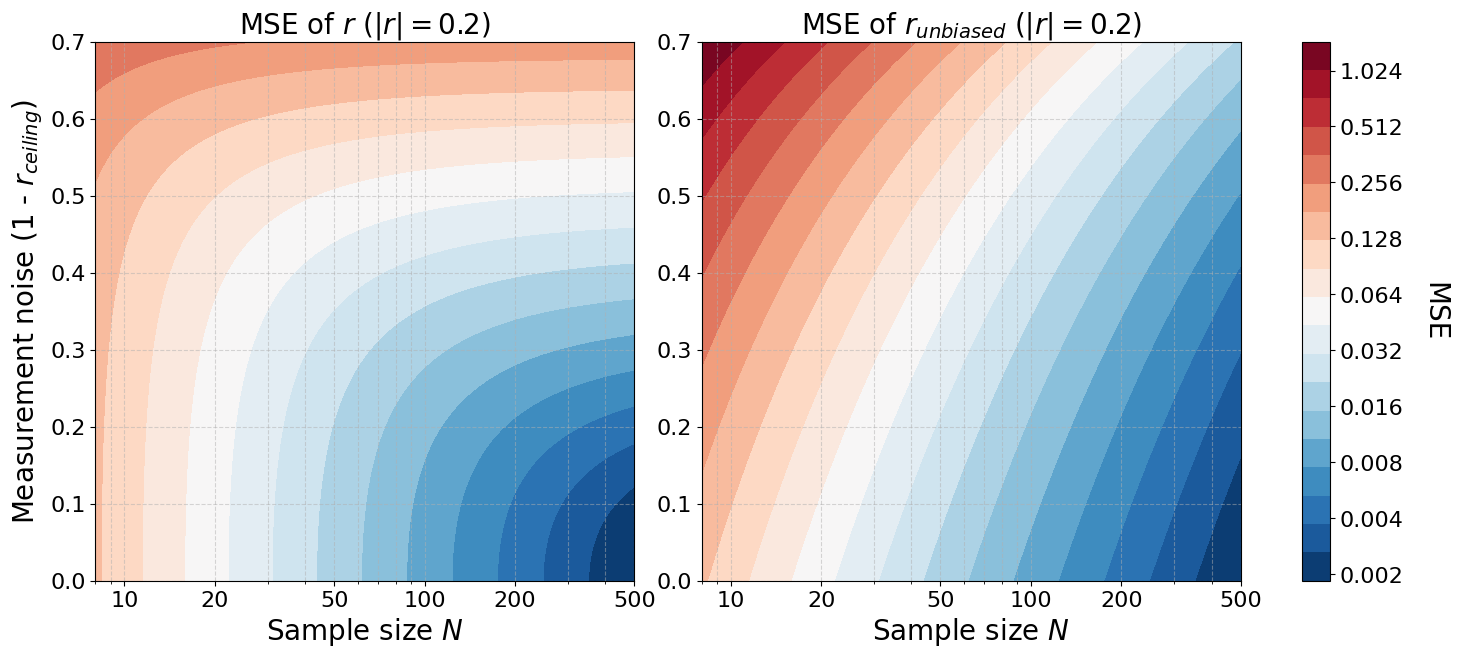

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/1493852416.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


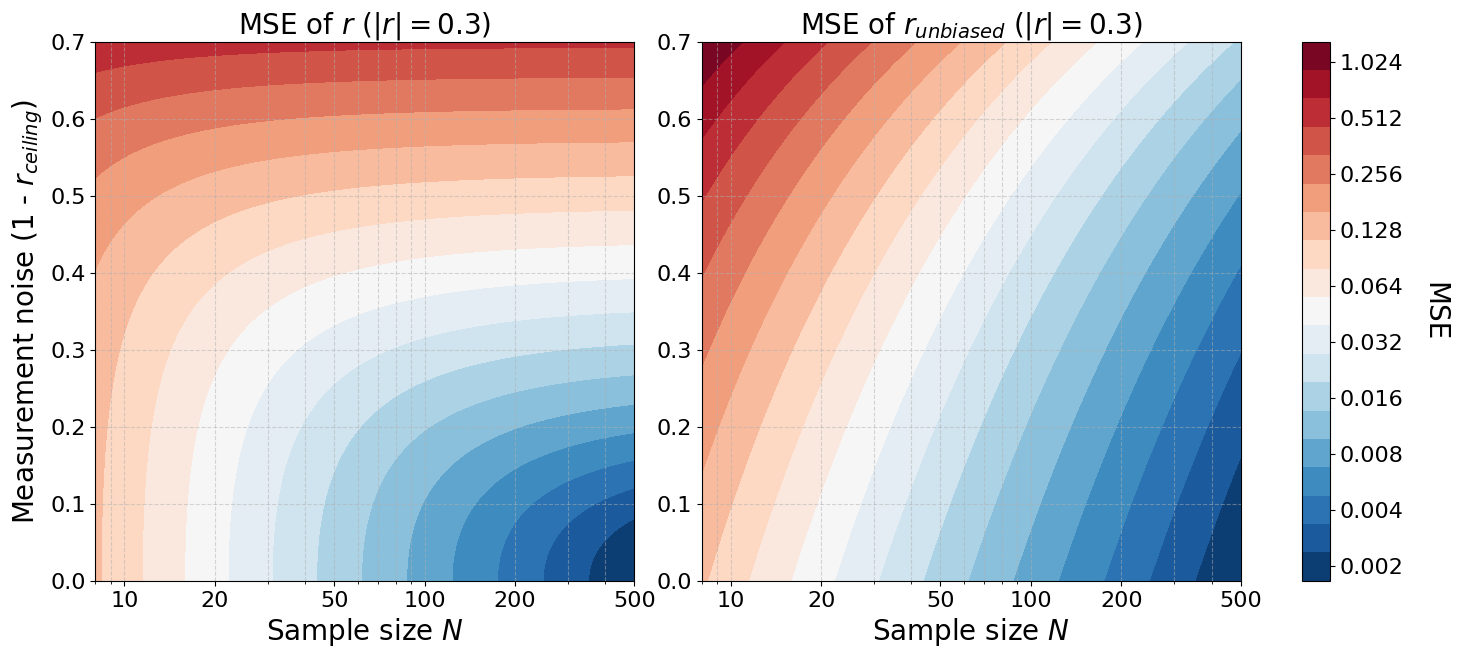

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/1493852416.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


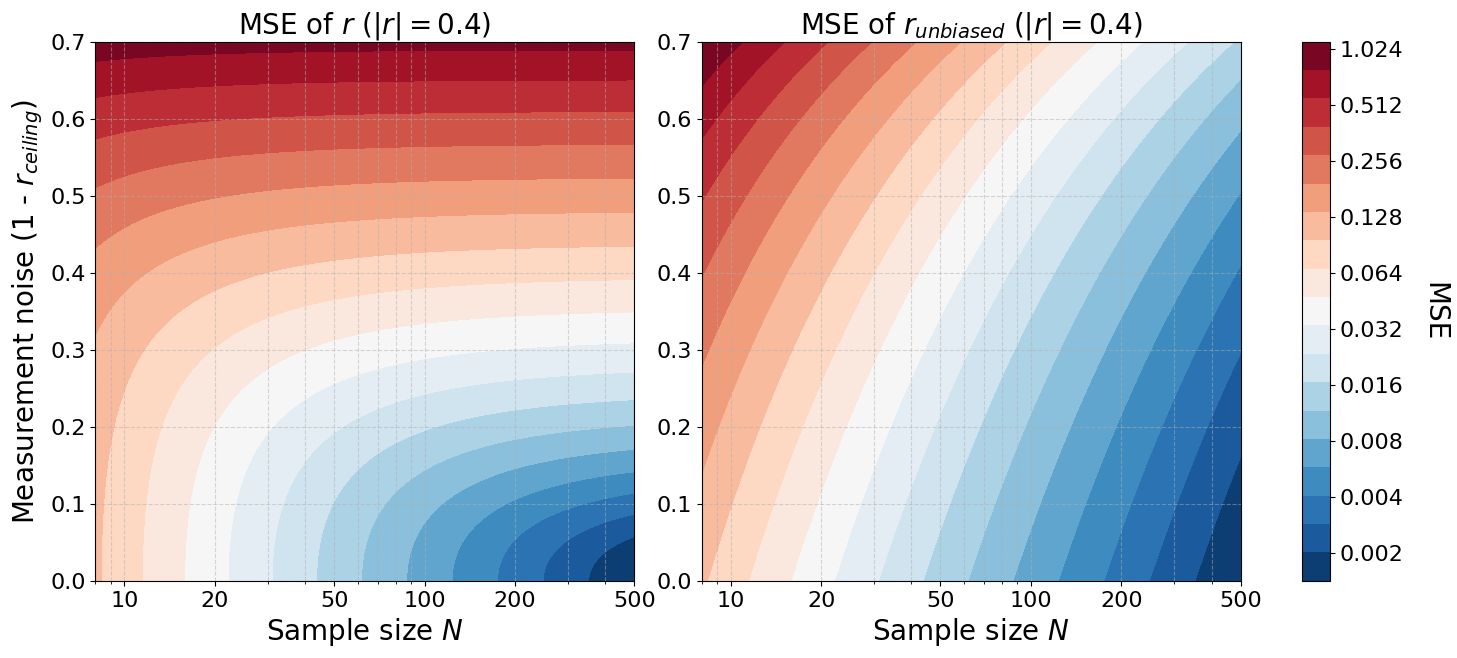

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/1493852416.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


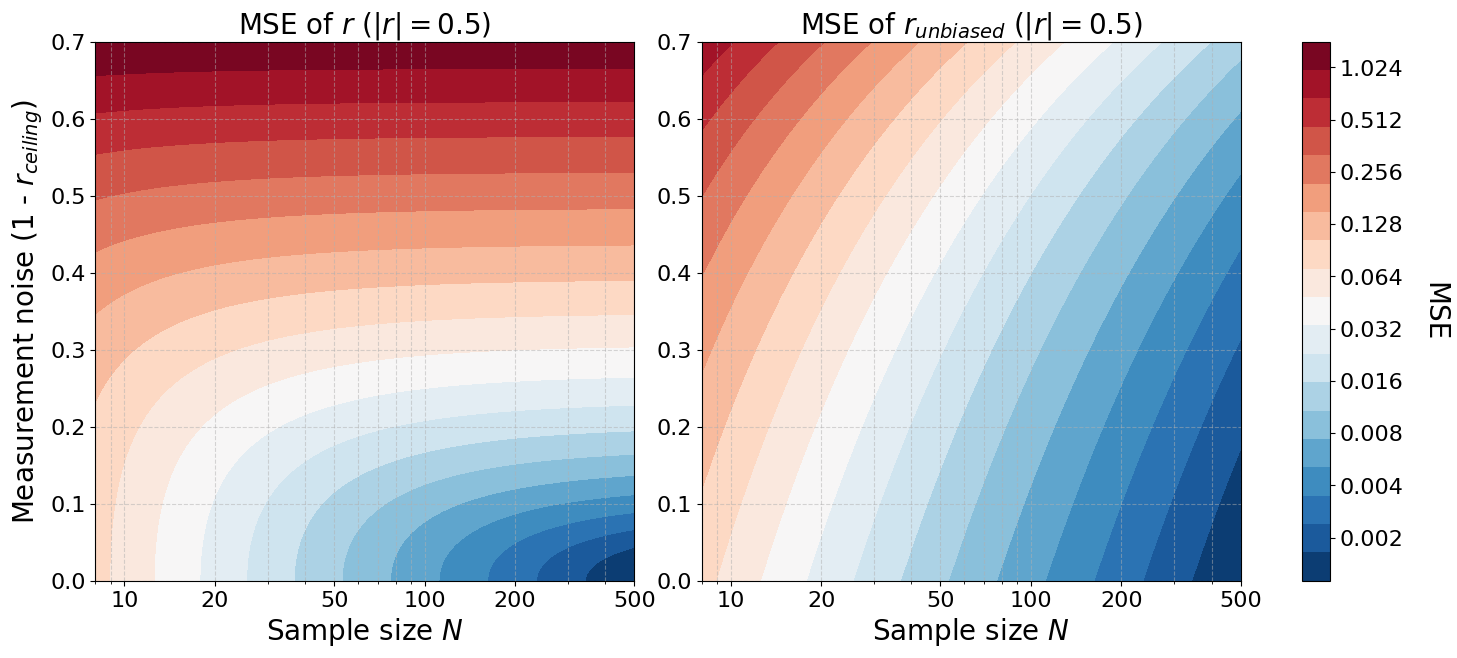

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter, FixedLocator
from matplotlib.colors import LogNorm

def calculate_mse_components(n, r_ceiling, r):
    """
    Calculates MSE of r (raw) and MSE of r_unbiased separately.
    
    Returns
    -------
    mse_raw : array
        MSE of the uncorrected correlation
    mse_unbiased : array
        MSE of the attenuation-corrected correlation
    """
    rho = r / r_ceiling
    var_r = ((1 - r**2)**2) / (n - 1)
    bias_squared = (rho * (1 - r_ceiling))**2
    mse_raw = var_r + bias_squared
    mse_unbiased = var_r / (r_ceiling**2)
    
    return mse_raw, mse_unbiased


def plot_mse_heatmaps(r_value):
    """
    Plot side-by-side heatmaps for MSE of r and MSE of r_unbiased.
    """
    # --- Configuration ---
    n_min, n_max = 8, 500
    r_min, r_max = 0.3, 1.0

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    r_range = np.linspace(r_min, r_max, 500)
    n_grid, r_ceiling_grid = np.meshgrid(n_range, r_range)

    # Calculate MSE components
    mse_raw, mse_unbiased = calculate_mse_components(n_grid, r_ceiling_grid, r_value)

    # --- Plotting with gridspec for colorbar sizing ---
    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    cax = fig.add_subplot(gs[2])
    
    axes = [ax1, ax2]
    data_list = [mse_raw, mse_unbiased]
    titles = [rf'MSE of $r$ ($|r| = {r_value}$)', rf'MSE of $r_{{unbiased}}$ ($|r| = {r_value}$)']
    
    # Common colorbar range for comparison (log scale)
    vmin = min(mse_raw.min(), mse_unbiased.min())
    vmax = max(mse_raw.max(), mse_unbiased.max())
    norm = LogNorm(vmin=vmin, vmax=vmax)
    
    # Define levels in log space
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 20)
    
    for idx, (ax, data, title) in enumerate(zip(axes, data_list, titles)):
        # Create the filled contour plot
        cp = ax.contourf(n_grid, r_ceiling_grid, data, levels=levels, cmap='RdBu_r', norm=norm)
        
        # --- Log Scale Configuration ---
        ax.set_xscale('log')
        ax.set_ylim(1.0, 0.3)

        ticks = [10, 20, 50, 100, 200, 500]
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        ax.xaxis.set_major_formatter(ScalarFormatter())

        # --- Y-Axis Customization (Measurement Noise) ---
        def noise_formatter(x, pos):
            return f"{1 - x:.1f}"

        ax.yaxis.set_major_formatter(FuncFormatter(noise_formatter))
        
        r_ceil_ticks = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
        ax.set_yticks(r_ceil_ticks)

        # Labels and Title
        ax.set_xlabel('Sample size $N$', fontsize=20)
        if idx == 0:
            ax.set_ylabel(r'Measurement noise (1 - $r_{ceiling}$)', fontsize=20)
        ax.set_title(title, fontsize=20)
        ax.tick_params(axis='both', labelsize=16)

        ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
        
        # Make plot square
        ax.set_box_aspect(1)
    
    # Add colorbar
    cbar = fig.colorbar(cp, cax=cax)
    cbar.set_label('MSE', rotation=270, labelpad=32, fontsize=20)

    # Set specific tick locations
    tick_locations = [0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128, 0.256, 0.512, 1.024]
    # Filter to only include ticks within the data range
    tick_locations = [t for t in tick_locations if vmin <= t <= vmax]
    cbar.set_ticks(tick_locations)

    # Format labels as regular decimals
    def mse_formatter(x, pos):
        if x >= 1:
            return f'{x:.3f}'
        elif x >= 0.1:
            return f'{x:.3f}'
        elif x >= 0.01:
            return f'{x:.3f}'
        else:
            return f'{x:.3f}'

    cbar.ax.yaxis.set_major_formatter(FuncFormatter(mse_formatter))
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout()
    plt.show()


def plot_all_mse_heatmaps(r_values=[0.2, 0.3, 0.4, 0.5]):
    """
    Plot MSE heatmaps for multiple r values in a grid.
    Rows: different r values
    Columns: MSE of r, MSE of r_unbiased
    """
    # --- Configuration ---
    n_min, n_max = 8, 500
    r_min, r_max = 0.3, 1.0

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    r_range = np.linspace(r_min, r_max, 500)
    n_grid, r_ceiling_grid = np.meshgrid(n_range, r_range)

    # Calculate global min/max for consistent colorbar
    all_mse_raw = []
    all_mse_unbiased = []
    for r_value in r_values:
        mse_raw, mse_unbiased = calculate_mse_components(n_grid, r_ceiling_grid, r_value)
        all_mse_raw.append(mse_raw)
        all_mse_unbiased.append(mse_unbiased)
    
    vmin = min(np.min(all_mse_raw), np.min(all_mse_unbiased))
    vmax = max(np.max(all_mse_raw), np.max(all_mse_unbiased))
    norm = LogNorm(vmin=vmin, vmax=vmax)
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 20)

    # --- Plotting ---
    n_rows = len(r_values)
    fig = plt.figure(figsize=(14, 6 * n_rows))
    gs = fig.add_gridspec(n_rows, 3, width_ratios=[1, 1, 0.05], wspace=0.15, hspace=0.25)
    
    for row_idx, r_value in enumerate(r_values):
        mse_raw, mse_unbiased = all_mse_raw[row_idx], all_mse_unbiased[row_idx]
        data_list = [mse_raw, mse_unbiased]
        titles = [rf'MSE of $r$', rf'MSE of $r_{{unbiased}}$']
        
        for col_idx, (data, title) in enumerate(zip(data_list, titles)):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            # Create the filled contour plot
            cp = ax.contourf(n_grid, r_ceiling_grid, data, levels=levels, cmap='RdBu_r', norm=norm)
            
            # --- Log Scale Configuration ---
            ax.set_xscale('log')
            ax.set_ylim(1.0, 0.3)

            ticks = [10, 20, 50, 100, 200, 500]
            ax.set_xticks(ticks)
            ax.set_xticklabels([str(t) for t in ticks])
            ax.xaxis.set_major_formatter(ScalarFormatter())

            # --- Y-Axis Customization (Measurement Noise) ---
            def noise_formatter(x, pos):
                return f"{1 - x:.1f}"

            ax.yaxis.set_major_formatter(FuncFormatter(noise_formatter))
            
            r_ceil_ticks = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
            ax.set_yticks(r_ceil_ticks)

            # Labels
            if row_idx == n_rows - 1:
                ax.set_xlabel('Sample size $N$', fontsize=20)
            if col_idx == 0:
                ax.set_ylabel(r'Measurement noise (1 - $r_{ceiling}$)', fontsize=20)
            
            # Title with r value
            ax.set_title(f'{title} ($|r| = {r_value}$)', fontsize=20)
            ax.tick_params(axis='both', labelsize=16)

            ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
            
            # Make plot square
            ax.set_box_aspect(1)
    
    # Add shared colorbar
    cax = fig.add_subplot(gs[:, 2])
    cbar = fig.colorbar(cp, cax=cax)
    cbar.set_label('MSE', rotation=270, labelpad=32, fontsize=20)
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Option 1: Plot each r value separately (2 panels each)
    for r_val in [0.2, 0.3, 0.4, 0.5]:
        plot_mse_heatmaps(r_val)
    
    # Option 2: Plot all r values in one large grid (8 panels total)
    # plot_all_mse_heatmaps([0.2, 0.3, 0.4, 0.5])

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/2204622606.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


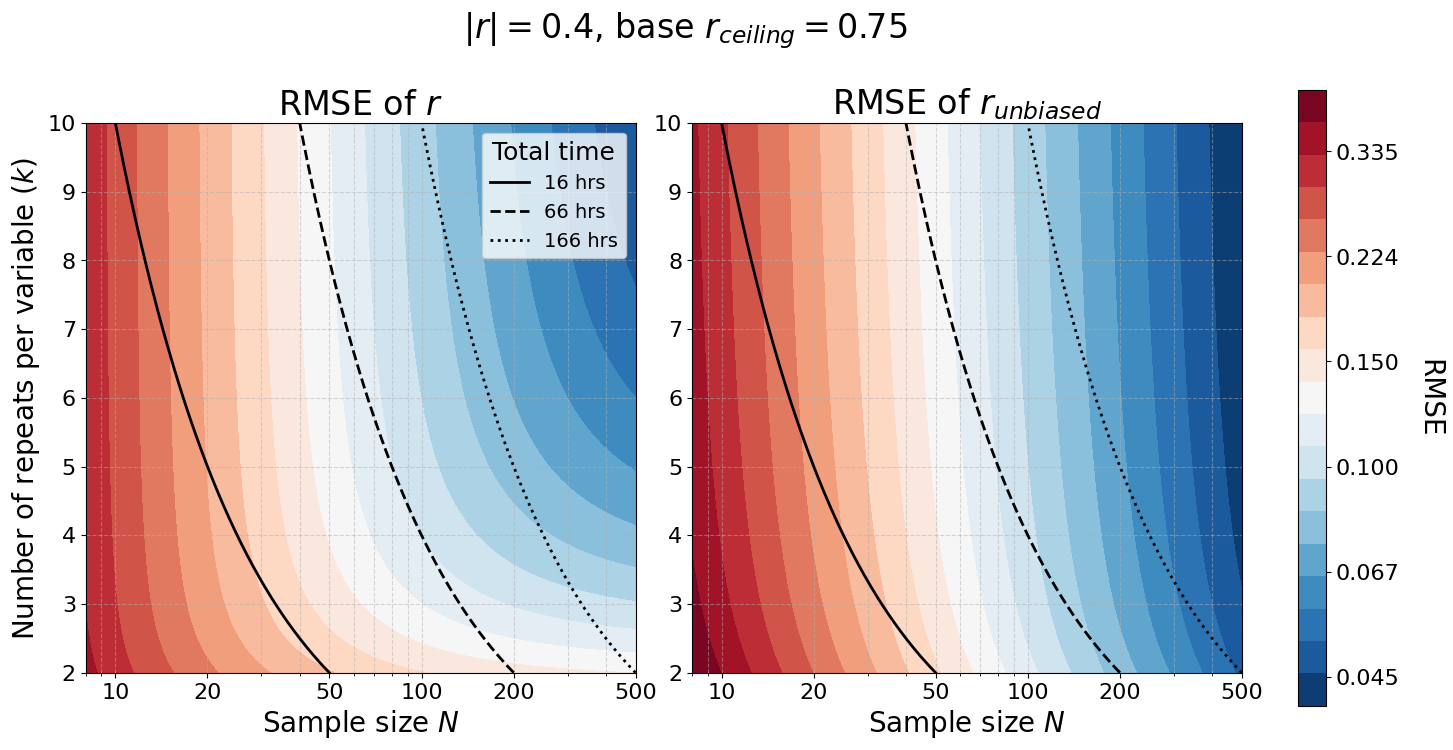

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter, FixedLocator
from matplotlib.colors import LogNorm

def calculate_r_ceiling_from_k(k, base_r_ceiling=0.75, base_k=2):
    """
    Calculate r_ceiling for a given number of repeats k.
    
    Given r_ceiling = between_var / (between_var + within_var/k),
    we derive the variance ratio from the base case and apply it to other k values.
    """
    variance_ratio = base_k * (1 - base_r_ceiling) / base_r_ceiling
    return 1 / (1 + variance_ratio / k)


def calculate_rmse_components(n, r_ceiling, r):
    """
    Calculates RMSE of r (raw) and RMSE of r_unbiased separately.
    """
    rho = r / r_ceiling
    var_r = ((1 - r**2)**2) / (n - 1)
    bias_squared = (rho * (1 - r_ceiling))**2
    mse_raw = var_r + bias_squared
    mse_unbiased = var_r / (r_ceiling**2)
    
    return np.sqrt(mse_raw), np.sqrt(mse_unbiased)


def calculate_n_for_time(total_time, k, base_time=20, time_per_repeat=10, base_k=2):
    """
    Calculate number of observers for a given total time and k repeats.
    """
    time_per_observer = base_time + (k - base_k) * time_per_repeat
    return total_time / time_per_observer


def plot_rmse_heatmaps(r_value, base_r_ceiling=0.75, base_k=2, 
                      iso_times=[4000, 6000, 10000], show_iso_temporal=True):
    """
    Plot side-by-side heatmaps for RMSE of r and RMSE of r_unbiased.
    """
    # --- Configuration ---
    n_min, n_max = 8, 500
    k_min, k_max = 2, 10

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    k_range = np.linspace(k_min, k_max, 500)
    n_grid, k_grid = np.meshgrid(n_range, k_range)
    
    r_ceiling_grid = calculate_r_ceiling_from_k(k_grid, base_r_ceiling, base_k)
    rmse_raw, rmse_unbiased = calculate_rmse_components(n_grid, r_ceiling_grid, r_value)

    # --- Plotting with gridspec for colorbar sizing ---
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    cax = fig.add_subplot(gs[2])
    
    axes = [ax1, ax2]
    data_list = [rmse_raw, rmse_unbiased]
    titles = [r'RMSE of $r$', r'RMSE of $r_{unbiased}$']
    
    # Common colorbar range for comparison (log scale)
    vmin = min(rmse_raw.min(), rmse_unbiased.min())
    vmax = max(rmse_raw.max(), rmse_unbiased.max())
    norm = LogNorm(vmin=vmin, vmax=vmax)
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 20)
    
    # Iso-temporal contour styles
    iso_colors = ['black', 'black', 'black']
    iso_linestyles = ['-', '--', ':']
    
    for idx, (ax, data, title) in enumerate(zip(axes, data_list, titles)):
        # Create the filled contour plot
        cp = ax.contourf(n_grid, k_grid, data, levels=levels, cmap='RdBu_r', norm=norm)
        
        # --- Add iso-temporal contours ---
        if show_iso_temporal:
            k_for_contour = np.linspace(k_min, k_max, 200)
            for i, (total_time, color, ls) in enumerate(zip(iso_times, iso_colors, iso_linestyles)):
                n_for_contour = calculate_n_for_time(total_time, k_for_contour)
                mask = (n_for_contour >= n_min) & (n_for_contour <= n_max)
                label = f'{total_time // 60:.0f} hrs' if idx == 0 else None
                ax.plot(n_for_contour[mask], k_for_contour[mask], 
                       color=color, linestyle=ls, linewidth=2, label=label)
        
        # --- Log Scale Configuration for X-axis ---
        ax.set_xscale('log')

        ticks = [10, 20, 50, 100, 200, 500]
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        ax.xaxis.set_major_formatter(ScalarFormatter())

        # --- Y-Axis Configuration (Number of Repeats) ---
        ax.set_ylim(k_min, k_max)
        k_ticks = [2, 3, 4, 5, 6, 7, 8, 9, 10]
        ax.set_yticks(k_ticks)

        # Labels and Title
        ax.set_xlabel('Sample size $N$', fontsize=20)
        if idx == 0:
            ax.set_ylabel('Number of repeats per variable ($k$)', fontsize=20)
            legend = ax.legend(loc='upper right', fontsize=14, title='Total time')
            legend.get_title().set_fontsize(18)
        ax.set_title(title, fontsize=24)
        ax.tick_params(axis='both', labelsize=16)

        ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
        ax.set_box_aspect(1)
    
    # Add main title (higher and larger)
    fig.suptitle(rf'$|r| = {r_value}$, base $r_{{ceiling}} = {base_r_ceiling}$', fontsize=24, y=0.98)
    
    # Add colorbar
    cbar = fig.colorbar(cp, cax=cax)
    cbar.set_label('RMSE', rotation=270, labelpad=32, fontsize=20)

    tick_locations = np.geomspace(0.03, 0.5, 8)
    tick_locations = [t for t in tick_locations if vmin <= t <= vmax]
    cbar.set_ticks(tick_locations)

    def rmse_formatter(x, pos):
        return f'{x:.3f}'

    cbar.ax.yaxis.set_major_formatter(FuncFormatter(rmse_formatter))
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


def plot_all_rmse_heatmaps(r_values=[0.2, 0.3, 0.4, 0.5], base_r_ceiling=0.75, base_k=2,
                          iso_times=[4000, 6000, 10000], show_iso_temporal=True):
    """
    Plot RMSE heatmaps for multiple r values in a grid.
    """
    # --- Configuration ---
    n_min, n_max = 8, 500
    k_min, k_max = 2, 20

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    k_range = np.linspace(k_min, k_max, 500)
    n_grid, k_grid = np.meshgrid(n_range, k_range)
    
    r_ceiling_grid = calculate_r_ceiling_from_k(k_grid, base_r_ceiling, base_k)

    # Calculate global min/max for consistent colorbar
    all_rmse_raw = []
    all_rmse_unbiased = []
    for r_value in r_values:
        rmse_raw, rmse_unbiased = calculate_rmse_components(n_grid, r_ceiling_grid, r_value)
        all_rmse_raw.append(rmse_raw)
        all_rmse_unbiased.append(rmse_unbiased)
    
    vmin = min(np.min(all_rmse_raw), np.min(all_rmse_unbiased))
    vmax = max(np.max(all_rmse_raw), np.max(all_rmse_unbiased))
    norm = LogNorm(vmin=vmin, vmax=vmax)
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 20)

    # Iso-temporal contour styles
    iso_colors = ['black', 'black', 'black']
    iso_linestyles = ['-', '--', ':']

    # --- Plotting ---
    n_rows = len(r_values)
    fig = plt.figure(figsize=(14, 6.5 * n_rows))
    gs = fig.add_gridspec(n_rows, 3, width_ratios=[1, 1, 0.05], wspace=0.15, hspace=0.45)
    
    for row_idx, r_value in enumerate(r_values):
        rmse_raw, rmse_unbiased = all_rmse_raw[row_idx], all_rmse_unbiased[row_idx]
        data_list = [rmse_raw, rmse_unbiased]
        titles = [r'RMSE of $r$', r'RMSE of $r_{unbiased}$']
        
        for col_idx, (data, title) in enumerate(zip(data_list, titles)):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            cp = ax.contourf(n_grid, k_grid, data, levels=levels, cmap='RdBu_r', norm=norm)
            
            # --- Add iso-temporal contours ---
            if show_iso_temporal:
                k_for_contour = np.linspace(k_min, k_max, 200)
                for i, (total_time, color, ls) in enumerate(zip(iso_times, iso_colors, iso_linestyles)):
                    n_for_contour = calculate_n_for_time(total_time, k_for_contour)
                    mask = (n_for_contour >= n_min) & (n_for_contour <= n_max)
                    label = f'{total_time // 60:.0f} hrs' if (row_idx == 0 and col_idx == 0) else None
                    ax.plot(n_for_contour[mask], k_for_contour[mask], 
                           color=color, linestyle=ls, linewidth=2, label=label)
            
            # --- Log Scale Configuration for X-axis ---
            ax.set_xscale('log')

            ticks = [10, 20, 50, 100, 200, 500]
            ax.set_xticks(ticks)
            ax.set_xticklabels([str(t) for t in ticks])
            ax.xaxis.set_major_formatter(ScalarFormatter())

            # --- Y-Axis Configuration (Number of Repeats) ---
            ax.set_ylim(k_min, k_max)
            k_ticks = [2, 3, 4, 5, 6, 7, 8, 9, 10]
            ax.set_yticks(k_ticks)

            # Labels
            if row_idx == n_rows - 1:
                ax.set_xlabel('Sample size $N$', fontsize=20)
            if col_idx == 0:
                ax.set_ylabel('Number of repeats per variable ($k$)', fontsize=20)
            
            # Legend only on first plot
            if row_idx == 0 and col_idx == 0 and show_iso_temporal:
                legend = ax.legend(loc='upper right', fontsize=14, title='Total time')
                legend.get_title().set_fontsize(18)
            
            # Row title (centered above both panels)
            if col_idx == 0:
                ax.annotate(rf'$|r| = {r_value}$, base $r_{{ceiling}} = {base_r_ceiling}$', 
                           xy=(0.5, 1.18), xycoords='axes fraction',
                           fontsize=24, ha='center', va='bottom',
                           xytext=(1.08, 1.18), textcoords='axes fraction')
            
            ax.set_title(title, fontsize=24)
            ax.tick_params(axis='both', labelsize=16)

            ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
            ax.set_box_aspect(1)
    
    # Add shared colorbar
    cax = fig.add_subplot(gs[:, 2])
    cbar = fig.colorbar(cp, cax=cax)
    cbar.set_label('RMSE', rotation=270, labelpad=32, fontsize=20)
    
    tick_locations = np.geomspace(0.03, 0.5, 8)
    tick_locations = [t for t in tick_locations if vmin <= t <= vmax]
    cbar.set_ticks(tick_locations)

    def rmse_formatter(x, pos):
        return f'{x:.3f}'

    cbar.ax.yaxis.set_major_formatter(FuncFormatter(rmse_formatter))
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    plot_rmse_heatmaps(r_value=0.4, base_r_ceiling=0.75, base_k=2,
                      iso_times=[1000, 4000, 10000])

/var/folders/tv/bsvxxkg10s71322nv0drgww00000gn/T/ipykernel_44737/3918861911.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


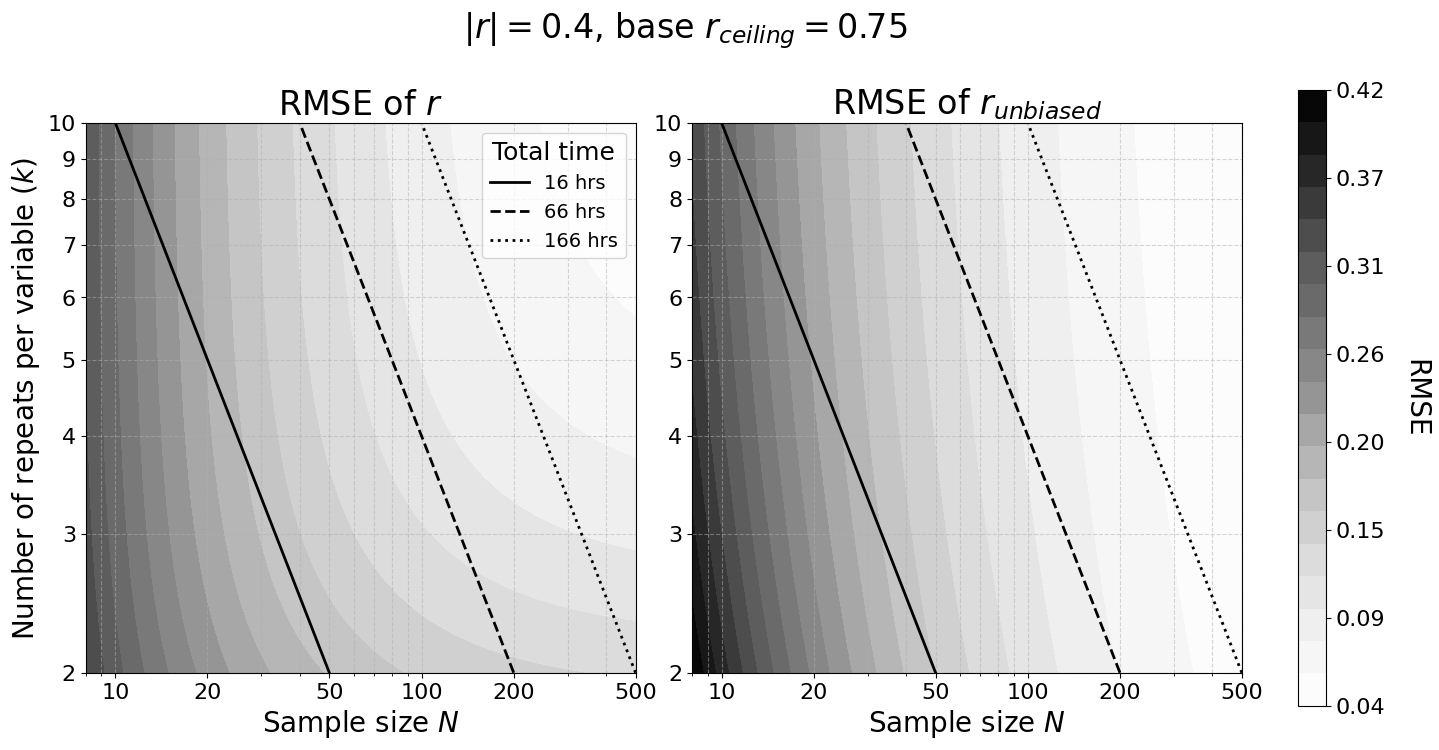

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter, FixedLocator
from matplotlib.colors import Normalize

def calculate_r_ceiling_from_k(k, base_r_ceiling=0.75, base_k=2):
    """
    Calculate r_ceiling for a given number of repeats k.
    
    Given r_ceiling = between_var / (between_var + within_var/k),
    we derive the variance ratio from the base case and apply it to other k values.
    """
    variance_ratio = base_k * (1 - base_r_ceiling) / base_r_ceiling
    return 1 / (1 + variance_ratio / k)


def calculate_rmse_components(n, r_ceiling, r):
    """
    Calculates RMSE of r (raw) and RMSE of r_unbiased separately.
    """
    rho = r / r_ceiling
    var_r = ((1 - r**2)**2) / (n - 1)
    bias_squared = (rho * (1 - r_ceiling))**2
    mse_raw = var_r + bias_squared
    mse_unbiased = var_r / (r_ceiling**2)
    
    return np.sqrt(mse_raw), np.sqrt(mse_unbiased)


def calculate_n_for_time(total_time, k, base_time=20, time_per_repeat=10, base_k=2):
    """
    Calculate number of observers for a given total time and k repeats.
    """
    time_per_observer = base_time + (k - base_k) * time_per_repeat
    return total_time / time_per_observer


def plot_rmse_heatmaps(r_value, base_r_ceiling=0.75, base_k=2, 
                      iso_times=[4000, 6000, 10000], show_iso_temporal=True):
    """
    Plot side-by-side heatmaps for RMSE of r and RMSE of r_unbiased.
    """
    # --- Configuration ---
    n_min, n_max = 8, 500
    k_min, k_max = 2, 10

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    k_range = np.logspace(np.log10(k_min), np.log10(k_max), 500)  # Log-spaced k
    n_grid, k_grid = np.meshgrid(n_range, k_range)
    
    r_ceiling_grid = calculate_r_ceiling_from_k(k_grid, base_r_ceiling, base_k)
    rmse_raw, rmse_unbiased = calculate_rmse_components(n_grid, r_ceiling_grid, r_value)

    # --- Plotting with gridspec for colorbar sizing ---
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    cax = fig.add_subplot(gs[2])
    
    axes = [ax1, ax2]
    data_list = [rmse_raw, rmse_unbiased]
    titles = [r'RMSE of $r$', r'RMSE of $r_{unbiased}$']
    
    # Common colorbar range for comparison (linear scale)
    vmin = min(rmse_raw.min(), rmse_unbiased.min())
    vmax = max(rmse_raw.max(), rmse_unbiased.max())
    norm = Normalize(vmin=vmin, vmax=vmax)
    levels = np.linspace(vmin, vmax, 20)
    
    # Iso-temporal contour styles
    iso_colors = ['black', 'black', 'black']
    iso_linestyles = ['-', '--', ':']
    
    for idx, (ax, data, title) in enumerate(zip(axes, data_list, titles)):
        # Create the filled contour plot
        cp = ax.contourf(n_grid, k_grid, data, levels=levels, cmap='Greys', norm=norm)
        
        # --- Add iso-temporal contours ---
        if show_iso_temporal:
            k_for_contour = np.linspace(k_min, k_max, 200)
            for i, (total_time, color, ls) in enumerate(zip(iso_times, iso_colors, iso_linestyles)):
                n_for_contour = calculate_n_for_time(total_time, k_for_contour)
                mask = (n_for_contour >= n_min) & (n_for_contour <= n_max)
                label = f'{total_time // 60:.0f} hrs' if idx == 0 else None
                ax.plot(n_for_contour[mask], k_for_contour[mask], 
                       color=color, linestyle=ls, linewidth=2, label=label)
        
        # --- Log Scale Configuration for X-axis ---
        ax.set_xscale('log')
        x_ticks = [10, 20, 50, 100, 200, 500]
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(t) for t in x_ticks])
        ax.xaxis.set_major_formatter(ScalarFormatter())

        # --- Log Scale Configuration for Y-axis ---
        ax.set_yscale('log')
        ax.set_ylim(k_min, k_max)
        k_ticks = [2, 3, 4, 5, 6, 7, 8, 9, 10]
        ax.set_yticks(k_ticks)
        ax.set_yticklabels([str(t) for t in k_ticks])
        ax.yaxis.set_major_formatter(ScalarFormatter())

        # Labels and Title
        ax.set_xlabel('Sample size $N$', fontsize=20)
        if idx == 0:
            ax.set_ylabel('Number of repeats per variable ($k$)', fontsize=20)
            legend = ax.legend(loc='upper right', fontsize=14, title='Total time')
            legend.get_title().set_fontsize(18)
        ax.set_title(title, fontsize=24)
        ax.tick_params(axis='both', labelsize=16)

        ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
        ax.set_box_aspect(1)
    
    # Add main title (higher and larger)
    fig.suptitle(rf'$|r| = {r_value}$, base $r_{{ceiling}} = {base_r_ceiling}$', fontsize=24, y=0.98)
    
    # Add colorbar
    cbar = fig.colorbar(cp, cax=cax)
    cbar.set_label('RMSE', rotation=270, labelpad=32, fontsize=20)

    # Linear tick locations
    tick_locations = np.linspace(vmin, vmax, 8)
    cbar.set_ticks(tick_locations)

    def rmse_formatter(x, pos):
        return f'{x:.2f}'

    cbar.ax.yaxis.set_major_formatter(FuncFormatter(rmse_formatter))
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


def plot_all_rmse_heatmaps(r_values=[0.2, 0.3, 0.4, 0.5], base_r_ceiling=0.75, base_k=2,
                          iso_times=[4000, 6000, 10000], show_iso_temporal=True):
    """
    Plot RMSE heatmaps for multiple r values in a grid.
    """
    # --- Configuration ---
    n_min, n_max = 8, 500
    k_min, k_max = 2, 10

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 500)
    k_range = np.logspace(np.log10(k_min), np.log10(k_max), 500)  # Log-spaced k
    n_grid, k_grid = np.meshgrid(n_range, k_range)
    
    r_ceiling_grid = calculate_r_ceiling_from_k(k_grid, base_r_ceiling, base_k)

    # Calculate global min/max for consistent colorbar
    all_rmse_raw = []
    all_rmse_unbiased = []
    for r_value in r_values:
        rmse_raw, rmse_unbiased = calculate_rmse_components(n_grid, r_ceiling_grid, r_value)
        all_rmse_raw.append(rmse_raw)
        all_rmse_unbiased.append(rmse_unbiased)
    
    vmin = min(np.min(all_rmse_raw), np.min(all_rmse_unbiased))
    vmax = max(np.max(all_rmse_raw), np.max(all_rmse_unbiased))
    norm = Normalize(vmin=vmin, vmax=vmax)
    levels = np.linspace(vmin, vmax, 20)

    # Iso-temporal contour styles
    iso_colors = ['black', 'black', 'black']
    iso_linestyles = ['-', '--', ':']

    # --- Plotting ---
    n_rows = len(r_values)
    fig = plt.figure(figsize=(14, 6.5 * n_rows))
    gs = fig.add_gridspec(n_rows, 3, width_ratios=[1, 1, 0.05], wspace=0.15, hspace=0.45)
    
    for row_idx, r_value in enumerate(r_values):
        rmse_raw, rmse_unbiased = all_rmse_raw[row_idx], all_rmse_unbiased[row_idx]
        data_list = [rmse_raw, rmse_unbiased]
        titles = [r'RMSE of $r$', r'RMSE of $r_{unbiased}$']
        
        for col_idx, (data, title) in enumerate(zip(data_list, titles)):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            cp = ax.contourf(n_grid, k_grid, data, levels=levels, cmap='Greys', norm=norm)
            
            # --- Add iso-temporal contours ---
            if show_iso_temporal:
                k_for_contour = np.linspace(k_min, k_max, 200)
                for i, (total_time, color, ls) in enumerate(zip(iso_times, iso_colors, iso_linestyles)):
                    n_for_contour = calculate_n_for_time(total_time, k_for_contour)
                    mask = (n_for_contour >= n_min) & (n_for_contour <= n_max)
                    label = f'{total_time // 60:.0f} hrs' if (row_idx == 0 and col_idx == 0) else None
                    ax.plot(n_for_contour[mask], k_for_contour[mask], 
                           color=color, linestyle=ls, linewidth=2, label=label)
            
            # --- Log Scale Configuration for X-axis ---
            ax.set_xscale('log')
            x_ticks = [10, 20, 50, 100, 200, 500]
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([str(t) for t in x_ticks])
            ax.xaxis.set_major_formatter(ScalarFormatter())

            # --- Log Scale Configuration for Y-axis ---
            ax.set_yscale('log')
            ax.set_ylim(k_min, k_max)
            k_ticks = [2, 3, 4, 5, 6, 7, 8, 9, 10]
            ax.set_yticks(k_ticks)
            ax.set_yticklabels([str(t) for t in k_ticks])
            ax.yaxis.set_major_formatter(ScalarFormatter())

            # Labels
            if row_idx == n_rows - 1:
                ax.set_xlabel('Sample size $N$', fontsize=20)
            if col_idx == 0:
                ax.set_ylabel('Number of repeats per variable ($k$)', fontsize=20)
            
            # Legend only on first plot
            if row_idx == 0 and col_idx == 0 and show_iso_temporal:
                legend = ax.legend(loc='upper right', fontsize=14, title='Total time')
                legend.get_title().set_fontsize(18)
            
            # Row title (centered above both panels)
            if col_idx == 0:
                ax.annotate(rf'$|r| = {r_value}$, base $r_{{ceiling}} = {base_r_ceiling}$', 
                           xy=(0.5, 1.18), xycoords='axes fraction',
                           fontsize=24, ha='center', va='bottom',
                           xytext=(1.08, 1.18), textcoords='axes fraction')
            
            ax.set_title(title, fontsize=24)
            ax.tick_params(axis='both', labelsize=16)

            ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)
            ax.set_box_aspect(1)
    
    # Add shared colorbar
    cax = fig.add_subplot(gs[:, 2])
    cbar = fig.colorbar(cp, cax=cax)
    cbar.set_label('RMSE', rotation=270, labelpad=32, fontsize=20)
    
    # Linear tick locations
    tick_locations = np.linspace(vmin, vmax, 8)
    cbar.set_ticks(tick_locations)

    def rmse_formatter(x, pos):
        return f'{x:.2f}'

    cbar.ax.yaxis.set_major_formatter(FuncFormatter(rmse_formatter))
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    plot_rmse_heatmaps(r_value=0.4, base_r_ceiling=0.75, base_k=2,
                      iso_times=[1000, 4000, 10000])

In [73]:
calculate_r_ceiling_from_k(4, base_r_ceiling=0.75, base_k=2)

0.8571428571428571

In [72]:
1-(.25/1.7)

0.8529411764705882

REPEAT WRT RHO

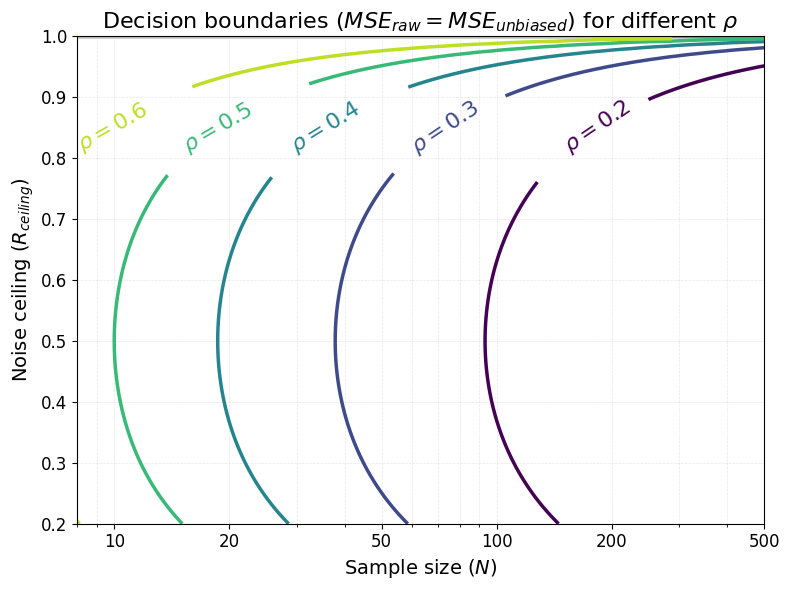

In [31]:
def calculate_mse_ratio(n, r_ceiling, rho):
    """
    Calculates the ratio of MSE_unbiased to MSE_raw based on:
    1. Var(R) ~= ((1 - rho^2)^2) / (N - 1)
    2. MSE_raw ~= Var(R) + [rho * (1 - R_ceiling)]^2
    3. MSE_unbiased ~= Var(R) / R_ceiling
    where rho ~= R / R_ceiling
    """
    # Calculate rho from R and R_ceiling
    var_r = ((1 - rho**2)**2) / (n - 1)
    
    # Equation [1]: MSE Raw
    # Note: The bias term is squared: [rho(1 - R_ceiling)]^2
    bias_squared = (rho * (1 - r_ceiling))**2
    mse_raw = var_r + bias_squared
    
    # Equation [2]: MSE Unbiased
    # Note: Image implies MSE_unbiased is Var(R) scaled by 1/R_ceiling
    mse_unbiased = var_r / r_ceiling
    
    return mse_unbiased / mse_raw

def solve_n_for_fixed_r_ceiling(r_ceil_target, N_grid, R_Ceiling_grid, Ratio_grid):
    """Finds N where Ratio=1.0 for fixed R_ceiling using interpolation."""
    idx = np.abs(R_Ceiling_grid[:, 0] - r_ceil_target).argmin()
    return np.interp(1.0, np.sort(Ratio_grid[idx]), N_grid[idx, np.argsort(Ratio_grid[idx])])

def plot_mse_ratio_contours():
    # --- Configuration ---
    # Contours for "rho" (True Construct Correlation)
    rho_values = [0.2, 0.3, 0.4, 0.5, 0.6]
    
    # Spacing adjustments for labels
    spacings = [50, 12, 10, 7, 1] 
    
    n_min, n_max = 8, 500
    r_ceil_min, r_ceil_max = 0.2, 1.0
    
    # Target Y-value (R_ceiling) for all labels (Horizontal alignment)
    # This replaces label_n_fixed
    label_r_ceil_fixed = 0.85

    # --- Data Generation ---
    n_range = np.logspace(np.log10(n_min), np.log10(n_max), 200)
    r_ceil_range = np.linspace(r_ceil_min, r_ceil_max, 200)
    
    # Grid: N on X, R_ceiling on Y
    N, R_Ceiling = np.meshgrid(n_range, r_ceil_range)

    # --- Plotting ---
    plt.figure(figsize=(8, 6))

    # Create distinct colors for the contours
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(rho_values)))

    for i, rho_val in enumerate(rho_values):
        # Calculate Ratio for current Rho
        Ratio = calculate_mse_ratio(N, R_Ceiling, rho_val)
        
        # Plot the contour line where Ratio = 1.0
        CS = plt.contour(
            N, R_Ceiling, Ratio, 
            levels=[1.0], 
            colors=[colors[i]], 
            linewidths=2.5
        )
        
        # Calculate the exact N where this curve crosses our target R_ceiling
        label_n_pos = solve_n_for_fixed_r_ceiling(label_r_ceil_fixed, N, R_Ceiling, Ratio)
        
        # Add label at the calculated manual position if it's within plot range
        if n_min <= label_n_pos <= n_max:
            plt.clabel(
                CS, 
                inline=True, 
                fontsize=16, 
                fmt={1.0: f'$\\rho = {rho_val}$'},
                manual=[(label_n_pos, label_r_ceil_fixed)],
                use_clabeltext=True,
                inline_spacing=spacings[i]
            )

    # --- Log Scale Configuration ---
    plt.xscale('log')
    
    # Ensure tick labels are readable integers
    ticks = [10, 20, 50, 100, 200, 500]
    plt.xticks(ticks, labels=[str(t) for t in ticks])
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())

    # Labels and Title
    plt.xlabel(r'Sample size ($N$)', fontsize=14)
    plt.ylabel(r'Noise ceiling ($R_{ceiling}$)', fontsize=14)
    plt.title(r'Decision boundaries ($MSE_{raw} = MSE_{unbiased}$) for different $\rho$', fontsize=16)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Restore full ylim
    plt.ylim(0.2, 1.0)

    plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_mse_ratio_contours()